# Decision Trees and Ensemble Boosting Techniques
## Complete Tutorial with Step-by-Step Explanations

**Course:** Advanced Data Science with Python  
**Session:** 4  
**Date:** January 28, 2026

---

## Table of Contents
1. [Introduction to Decision Trees](#section1)
2. [Entropy and Information Gain](#section2)
3. [Building Decision Trees with ID3/CART](#section3)
4. [Ensemble Learning - Introduction](#section4)
5. [AdaBoost (Adaptive Boosting)](#section5)
6. [Gradient Boosting](#section6)
7. [Comparison and Best Practices](#section7)

---
## 1. Introduction to Decision Trees <a id='section1'></a>

### What is a Decision Tree?
A **Decision Tree** is a supervised machine learning algorithm that:
- Makes predictions by learning simple decision rules from data features
- Represents decisions in a tree-like structure
- Can be used for both **Classification** and **Regression** tasks

### Key Components:
- **Root Node**: Starting point containing all data
- **Internal Nodes**: Decision points where data is split
- **Leaf Nodes**: Terminal nodes with final predictions
- **Branches**: Connections representing decision outcomes

### Advantages:
✓ Easy to understand and interpret  
✓ No data preprocessing required (scaling/normalization)  
✓ Handles both numerical and categorical data  
✓ Can model non-linear relationships  

### Import Required Libraries

In [1]:
# Data manipulation and numerical operations
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-darkgrid')

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


---
## 2. Entropy and Information Gain <a id='section2'></a>

### Understanding Entropy
**Entropy** measures the impurity or uncertainty in a dataset.

**Mathematical Formula:**
$$Entropy(S) = -\sum_{i=1}^{c} p_i \log_2(p_i)$$

Where:
- $S$ = dataset
- $c$ = number of classes
- $p_i$ = proportion of samples belonging to class $i$

**Properties:**
- Entropy = 0 → Perfect purity (all samples are same class)
- Entropy = 1 → Maximum impurity (samples equally distributed)

### Understanding Information Gain
**Information Gain** measures how much information a feature gives us about the target class.

**Formula:**
$$IG(S, A) = Entropy(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} \cdot Entropy(S_v)$$

**The feature with highest Information Gain is selected for splitting!**

In [2]:
# Function to calculate entropy
def calculate_entropy(column):
    """
    Calculate entropy for a given column.
    
    Entropy measures the disorder/impurity in the data.
    Lower entropy = more organized/pure data
    Higher entropy = more random/impure data
    
    Parameters:
    -----------
    column : pandas.Series
        The feature column to calculate entropy for
        
    Returns:
    --------
    float
        Entropy value (0 to log2(n) where n is number of unique values)
        
    Example:
    --------
    >>> data = pd.Series(['A', 'A', 'B', 'B'])
    >>> calculate_entropy(data)
    1.0  # Maximum entropy for 2 equally distributed classes
    """
    # Step 1: Get value counts with normalization
    # normalize=True returns proportions instead of counts
    # Example: ['A', 'A', 'B'] → {'A': 0.667, 'B': 0.333}
    value_counts = column.value_counts(normalize=True)
    
    # Step 2: Calculate entropy using the formula: -sum(p * log2(p))
    # We add 1e-9 (a tiny number) to avoid log(0) which is undefined
    # np.log2() computes logarithm base 2
    entropy = -sum(value_counts * np.log2(value_counts + 1e-9))
    
    return entropy


# Function to calculate information gain
def information_gain(df, split_attribute, target_attribute):
    """
    Calculate information gain for splitting on a particular attribute.
    
    Information Gain = How much uncertainty is reduced after splitting
    Higher Information Gain = Better feature for splitting
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The complete dataset
    split_attribute : str
        The feature we want to split on (e.g., 'Color', 'Size')
    target_attribute : str
        The target variable we're predicting (e.g., 'Fruit')
        
    Returns:
    --------
    float
        Information gain value (0 to entropy of target)
        
    Process:
    --------
    1. Calculate entropy of target before split
    2. Split data by the feature
    3. Calculate weighted entropy after split
    4. Information Gain = Entropy(before) - Entropy(after)
    """
    # Step 1: Calculate total entropy of target variable (before splitting)
    # This represents the uncertainty in the current dataset
    total_entropy = calculate_entropy(df[target_attribute])
    
    # Step 2: Get the distribution of values in split_attribute
    # normalize=True gives us the weight (proportion) of each value
    # Example: Color ['Red', 'Red', 'Yellow'] → {'Red': 0.667, 'Yellow': 0.333}
    value_counts = df[split_attribute].value_counts(normalize=True)
    
    # Step 3: Calculate weighted entropy after splitting
    weighted_entropy = 0
    
    # Iterate through each unique value and its proportion
    for value, weight in value_counts.items():
        # Get subset of data where split_attribute has this value
        # Example: Get all rows where Color == 'Red'
        subset = df[df[split_attribute] == value]
        
        # Calculate entropy of target in this subset
        subset_entropy = calculate_entropy(subset[target_attribute])
        
        # Add weighted entropy: weight * entropy
        # Larger subsets contribute more to the weighted entropy
        weighted_entropy += weight * subset_entropy
    
    # Step 4: Information Gain = Reduction in entropy
    # = Entropy before split - Weighted entropy after split
    info_gain = total_entropy - weighted_entropy
    
    return info_gain


print("✓ Entropy and Information Gain functions defined successfully!")
print("\nThese functions help us understand:")
print("  - How 'messy' our data is (Entropy)")
print("  - Which feature best organizes our data (Information Gain)")

✓ Entropy and Information Gain functions defined successfully!

These functions help us understand:
  - How 'messy' our data is (Entropy)
  - Which feature best organizes our data (Information Gain)


### Create Sample Dataset: Fruit Classification

In [3]:
# Create a simple fruit dataset for demonstration
# This dataset will help us understand how Decision Trees work
data = {
    'Fruit': ['Apple', 'Banana', 'Orange', 'Strawberry'],     # Target variable (what we want to predict)
    'Color': ['Red', 'Yellow', 'Orange', 'Red'],              # Feature 1
    'Size': ['Large', 'Medium', 'Small', 'Small'],            # Feature 2
    'Sweetness': ['Sweet', 'Sweet', 'Sour', 'Sweet']          # Feature 3
}

df = pd.DataFrame(data)
print("Original Fruit Dataset:")
print(df)
print("\nDataset Shape:", df.shape)
print("Number of samples:", len(df))
print("Number of features:", len(df.columns) - 1)  # Excluding target column

Original Fruit Dataset:
        Fruit   Color    Size Sweetness
0       Apple     Red   Large     Sweet
1      Banana  Yellow  Medium     Sweet
2      Orange  Orange   Small      Sour
3  Strawberry     Red   Small     Sweet

Dataset Shape: (4, 4)
Number of samples: 4
Number of features: 3


### Calculate Entropy for Each Feature

In [4]:
# Calculate entropy for each feature (excluding the target 'Fruit')
# This tells us how 'mixed up' each feature is

print("=" * 60)
print("ENTROPY ANALYSIS")
print("=" * 60)
print("\nEntropy measures disorder in each feature:")
print("  - Lower entropy = more organized/predictable")
print("  - Higher entropy = more random/diverse\n")

for col in df.columns[1:]:  # Skip 'Fruit' column (index 0)
    entropy = calculate_entropy(df[col])
    print(f"Entropy of {col:12s}: {entropy:.4f}")
    
    # Provide interpretation
    if entropy < 1.0:
        print(f"  → {col} has relatively low entropy (more organized)")
    elif entropy > 1.4:
        print(f"  → {col} has high entropy (very diverse values)")
    else:
        print(f"  → {col} has moderate entropy")
    print()

ENTROPY ANALYSIS

Entropy measures disorder in each feature:
  - Lower entropy = more organized/predictable
  - Higher entropy = more random/diverse

Entropy of Color       : 1.5000
  → Color has high entropy (very diverse values)

Entropy of Size        : 1.5000
  → Size has high entropy (very diverse values)

Entropy of Sweetness   : 0.8113
  → Sweetness has relatively low entropy (more organized)



### Calculate Information Gain for Each Feature

In [5]:
# Calculate Information Gain for each feature
# This tells us which feature is BEST for predicting the Fruit type

print("=" * 60)
print("INFORMATION GAIN ANALYSIS")
print("=" * 60)
print("\nInformation Gain = How useful each feature is for prediction:")
print("  - Higher IG = Better feature for splitting")
print("  - Lower IG = Less useful feature\n")

target_attribute = 'Fruit'  # What we're trying to predict
ig_results = {}  # Store results for comparison

for col in df.columns[1:]:  # Check each feature
    info_gain_value = information_gain(df, col, target_attribute)
    ig_results[col] = info_gain_value
    print(f"Information Gain of {col:12s}: {info_gain_value:.4f}")

# Find the best feature
best_feature = max(ig_results, key=ig_results.get)
print("\n" + "="*60)
print(f"🏆 BEST FEATURE: {best_feature}")
print(f"   Information Gain: {ig_results[best_feature]:.4f}")
print("="*60)
print(f"\nConclusion: '{best_feature}' should be used as the ROOT NODE")
print("because it provides the most information about the Fruit type!")

INFORMATION GAIN ANALYSIS

Information Gain = How useful each feature is for prediction:
  - Higher IG = Better feature for splitting
  - Lower IG = Less useful feature

Information Gain of Color       : 1.5000
Information Gain of Size        : 1.5000
Information Gain of Sweetness   : 0.8113

🏆 BEST FEATURE: Color
   Information Gain: 1.5000

Conclusion: 'Color' should be used as the ROOT NODE
because it provides the most information about the Fruit type!


---
## 3. Building Decision Trees with CART <a id='section3'></a>

### CART (Classification and Regression Trees)
CART is the most popular algorithm for building decision trees in scikit-learn.

**Key Features:**
- Creates **binary splits** (two branches per node)
- Uses **Gini Index** (default) or **Entropy** as splitting criterion
- Handles both **classification** and **regression**
- Supports **numerical** and **categorical** data

### Step 1: Encode Categorical Variables

In [ ]:
# Machine learning algorithms require numerical input
# LabelEncoder converts categorical data (text) to numerical labels

# Create a copy of the dataframe to preserve original data
df_encoded = df.copy()

# Initialize LabelEncoder
# LabelEncoder assigns a unique integer to each unique category
# Example: ['Red', 'Yellow', 'Orange'] → [0, 1, 2]
le = LabelEncoder()

print("Encoding categorical variables to numerical values...\n")

# Encode each column
for col in df_encoded.columns:
    print(f"Encoding {col}:")
    # Show original values
    print(f"  Original: {df_encoded[col].tolist()}")
    
    # Apply encoding
    # fit_transform: learns the categories and transforms them
    df_encoded[col] = le.fit_transform(df_encoded[col])
    
    # Show encoded values
    print(f"  Encoded:  {df_encoded[col].tolist()}")
    print()

print("Encoded Dataset:")
print(df_encoded)
print("\n✓ All categorical variables converted to numerical format!")

### Step 2: Prepare Features and Target

In [7]:
# Separate features (X) and target (y)
# Convention: X = features (independent variables), y = target (dependent variable)

# Features: Variables used to make predictions
# We'll use only 'Color' feature for simplicity
X = df_encoded[['Color']]
#df[[]] means we are selecting a DataFrame with just the 'Color' column

# Target: Variable we want to predict
y = df_encoded['Fruit']

print("Features (X):")
print(X)
print(f"\nShape: {X.shape} → {X.shape[0]} samples, {X.shape[1]} feature(s)")

print("\n" + "="*60)
print("\nTarget (y):")
print(y)
print(f"\nShape: {y.shape} → {y.shape[0]} samples")
print("\nUnique classes:", y.unique())
print("Number of classes:", len(y.unique()))

Features (X):
   Color
0      1
1      2
2      0
3      1

Shape: (4, 1) → 4 samples, 1 feature(s)


Target (y):
0    0
1    1
2    2
3    3
Name: Fruit, dtype: int64

Shape: (4,) → 4 samples

Unique classes: [0 1 2 3]
Number of classes: 4


### Step 3: Split Data into Training and Testing Sets

In [8]:
# Split data: 60% training, 40% testing
# Why split? To evaluate model performance on unseen data

# train_test_split parameters:
# - X, y: features and target
# - test_size: proportion of dataset for testing (0.4 = 40%)
# - random_state: seed for reproducibility (same split every time)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.4,      # 40% for testing, 60% for training
    random_state=42     # Ensures same split every time
)

print("Data Split Summary:")
print("=" * 60)
print(f"Total samples:        {len(X)}")
print(f"Training samples:     {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing samples:      {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print("\nTraining set (X_train, y_train):")
print("  - Used to build/train the model")
print("  - Model learns patterns from this data")
print("\nTesting set (X_test, y_test):")
print("  - Used to evaluate model performance")
print("  - Model has never seen this data before")
print("  - Simulates real-world predictions")

Data Split Summary:
Total samples:        4
Training samples:     2 (50%)
Testing samples:      2 (50%)

Training set (X_train, y_train):
  - Used to build/train the model
  - Model learns patterns from this data

Testing set (X_test, y_test):
  - Used to evaluate model performance
  - Model has never seen this data before
  - Simulates real-world predictions


### Step 4: Build and Train Decision Tree Model

In [9]:
# Create Decision Tree Classifier
# DecisionTreeClassifier builds a tree-based classification model

# Key Parameters:
# - criterion: How to measure split quality
#   * 'gini': Gini impurity (default, faster)
#   * 'entropy': Information gain (what we calculated manually)
# - random_state: For reproducibility
# - max_depth: Maximum depth of tree (prevents overfitting)
# - min_samples_split: Minimum samples needed to split a node

DecisionTree = DecisionTreeClassifier(
    criterion='entropy',    # Use entropy (ID3-style)
    random_state=42        # Reproducible results
)

print("Decision Tree Classifier Created!")
print("\nModel Configuration:")
print(f"  - Criterion: {DecisionTree.criterion}")
print(f"  - Random State: {DecisionTree.random_state}")
print("\nTraining the model...")

# Train the model
# fit() method: learns patterns from training data
# It builds the decision tree by:
# 1. Selecting best feature using Information Gain
# 2. Splitting data based on that feature
# 3. Recursively repeating for each subset
DecisionTree.fit(X_train, y_train)

print("\n✓ Model trained successfully!")
print(f"\nTree Properties:")
print(f"  - Depth: {DecisionTree.get_depth()}")
print(f"  - Number of leaves: {DecisionTree.get_n_leaves()}")
print(f"  - Number of features: {DecisionTree.n_features_in_}")

Decision Tree Classifier Created!

Model Configuration:
  - Criterion: entropy
  - Random State: 42

Training the model...

✓ Model trained successfully!

Tree Properties:
  - Depth: 1
  - Number of leaves: 2
  - Number of features: 1


### Step 5: Make Predictions and Evaluate

In [12]:
# Make predictions on test set
# predict() method: uses trained tree to classify new data
y_pred = DecisionTree.predict(X_test)

print("Predictions on Test Set:")
print("=" * 60)

# Compare actual vs predicted
for i, (actual, predicted) in enumerate(zip(y_test, y_pred), 1):
    match = "✓" if actual == predicted else "✗"
    print(f"Sample {i}: Actual = {actual}, Predicted = {predicted} {match}")

#enumerate means we get index (i) along with actual and predicted values
#zip means we pair actual and predicted values together
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n{'='*60}")
print(f"Accuracy: {accuracy:.2%}")
print(f"{'='*60}")

Predictions on Test Set:
Sample 1: Actual = 1, Predicted = 0 ✗
Sample 2: Actual = 3, Predicted = 0 ✗

Accuracy: 0.00%


In [13]:
# Confusion Matrix: Shows correct and incorrect predictions
# Rows = Actual classes, Columns = Predicted classes
# Diagonal elements = Correct predictions
# Off-diagonal elements = Incorrect predictions

print("\nConfusion Matrix:")
print("=" * 60)
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("\nHow to read:")
print("  - Rows represent actual classes")
print("  - Columns represent predicted classes")
print("  - Diagonal = correct predictions")
print("  - Off-diagonal = misclassifications")

# Classification Report: Detailed metrics
print("\n" + "="*60)
print("Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred))

print("\nMetric Definitions:")
print("  - Precision: Of all predicted positives, how many are correct?")
print("  - Recall: Of all actual positives, how many did we find?")
print("  - F1-Score: Harmonic mean of precision and recall")
print("  - Support: Number of actual samples in each class")


Confusion Matrix:
[[0 0 0]
 [1 0 0]
 [1 0 0]]

How to read:
  - Rows represent actual classes
  - Columns represent predicted classes
  - Diagonal = correct predictions
  - Off-diagonal = misclassifications

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       1.0
           3       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0


Metric Definitions:
  - Precision: Of all predicted positives, how many are correct?
  - Recall: Of all actual positives, how many did we find?
  - F1-Score: Harmonic mean of precision and recall
  - Support: Number of actual samples in each class


### Step 6: Visualize Decision Tree

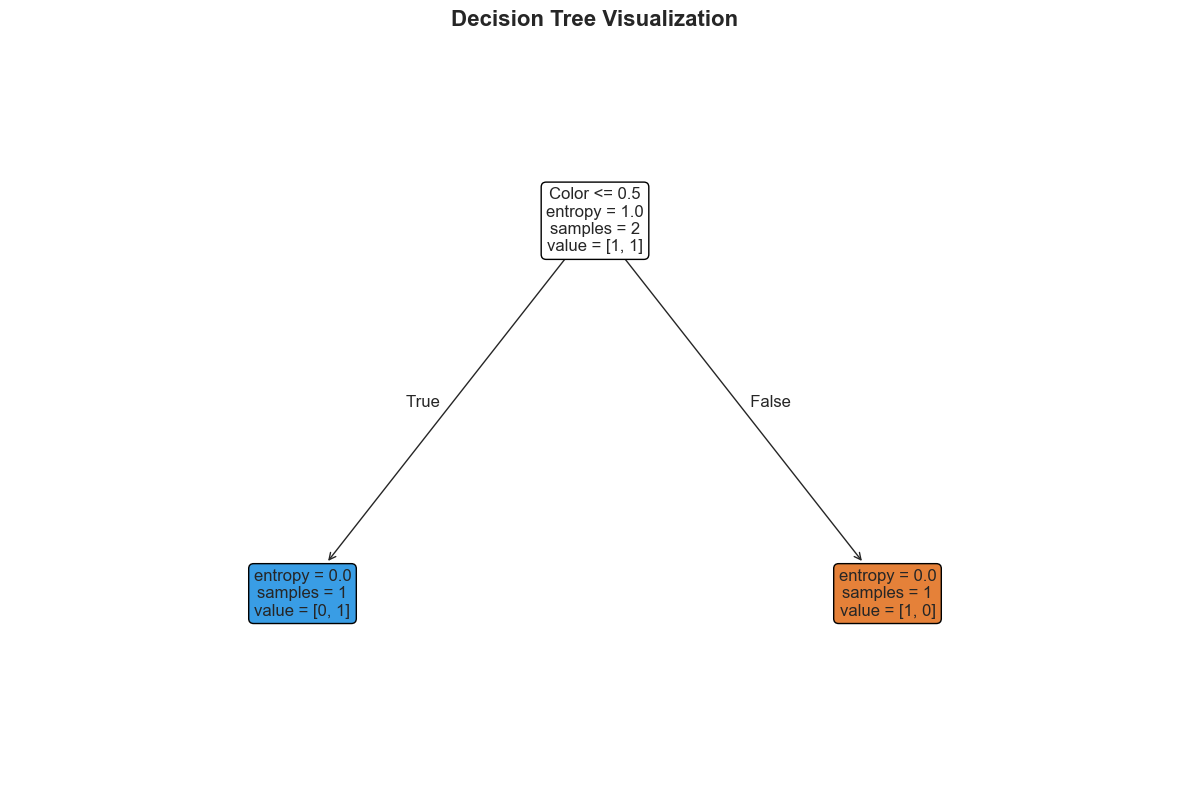


Tree Node Information:
  - Top box: Root node (all data)
  - Middle boxes: Decision nodes (splits)
  - Bottom boxes: Leaf nodes (predictions)
  - Colors: Represent different classes
  - Samples: Number of training samples in node
  - Value: Distribution of classes in node
  - Entropy/Gini: Impurity measure


In [14]:
# Visualize the decision tree structure
# This helps us understand how the model makes decisions

plt.figure(figsize=(12, 8))

# plot_tree parameters:
# - filled: Color nodes by class majority
# - feature_names: Names of features
# - class_names: Names of target classes
# - rounded: Rounded node boxes
# - fontsize: Text size

plot_tree(
    DecisionTree,
    feature_names=['Color'],
    filled=True,           # Color by class
    rounded=True,          # Rounded boxes
    fontsize=12
)

plt.title('Decision Tree Visualization', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTree Node Information:")
print("  - Top box: Root node (all data)")
print("  - Middle boxes: Decision nodes (splits)")
print("  - Bottom boxes: Leaf nodes (predictions)")
print("  - Colors: Represent different classes")
print("  - Samples: Number of training samples in node")
print("  - Value: Distribution of classes in node")
print("  - Entropy/Gini: Impurity measure")

---
## 4. Ensemble Learning - Introduction <a id='section4'></a>

### What is Ensemble Learning?
**Ensemble Learning** combines multiple models to create a stronger predictor.

**Philosophy:** "Wisdom of the crowd" - Multiple weak learners → One strong learner

### Types of Ensemble Methods:

#### 1. **Bagging (Bootstrap Aggregating)**
- Train models **in parallel** on different subsets
- Combine predictions by **voting** (classification) or **averaging** (regression)
- **Example:** Random Forest
- **Goal:** Reduce variance (prevent overfitting)

#### 2. **Boosting** ⭐ (Our Focus)
- Train models **sequentially**
- Each model corrects errors of previous models
- **Examples:** AdaBoost, Gradient Boosting
- **Goal:** Reduce bias (improve accuracy)

#### 3. **Stacking**
- Train multiple diverse models
- Use another model to combine their predictions
- **Goal:** Leverage strengths of different algorithms

### Why Use Boosting?
✓ **Higher accuracy** than single models  
✓ **Reduces bias** and variance  
✓ **Handles complex patterns**  
✓ **Feature importance** analysis  
✓ **State-of-the-art** results in competitions  

---
## 5. AdaBoost (Adaptive Boosting) <a id='section5'></a>

### How AdaBoost Works:

**Step-by-Step Process:**

1. **Initialize**: Give all samples equal weight (1/n)
2. **Build weak learner**: Train decision tree on weighted data
3. **Calculate error**: Find misclassified samples
4. **Update weights**:
   - **Increase** weight of misclassified samples (focus more on them)
   - **Decrease** weight of correctly classified samples
5. **Repeat**: Build next weak learner on re-weighted data
6. **Combine**: Final prediction = weighted vote of all learners

**Key Insight:** Each model focuses more on examples that previous models got wrong!

### Mathematical Formulation:
- **Model weight:** $\alpha_t = \frac{1}{2} \ln\left(\frac{1-\epsilon_t}{\epsilon_t}\right)$
- **Sample weight update:** $w_i^{(t+1)} = w_i^{(t)} \cdot e^{\alpha_t \cdot \mathbb{1}(y_i \neq h_t(x_i))}$

Where:
- $\epsilon_t$ = error rate of model $t$
- $\alpha_t$ = weight of model $t$ in final prediction
- $w_i$ = weight of sample $i$

### Classification Example with AdaBoost

In [ ]:
# Create a larger dataset for better demonstration
# Expanding our fruit dataset with more samples

extended_data = {
    'Fruit': ['Apple', 'Banana', 'Orange', 'Strawberry', 'Apple', 'Banana', 
              'Orange', 'Apple', 'Strawberry', 'Banana'],
    'Color': ['Red', 'Yellow', 'Orange', 'Red', 'Green', 'Yellow', 
              'Orange', 'Red', 'Red', 'Yellow'],
    'Size': ['Large', 'Medium', 'Small', 'Small', 'Large', 'Medium',
             'Medium', 'Large', 'Small', 'Large'],
    'Sweetness': ['Sweet', 'Sweet', 'Sour', 'Sweet', 'Sour', 'Sweet',
                  'Sour', 'Sweet', 'Sweet', 'Sweet']
}

df_extended = pd.DataFrame(extended_data)
print("Extended Fruit Dataset:")
print(df_extended)
print(f"\nDataset size: {len(df_extended)} samples")

In [ ]:
# Encode the extended dataset
df_extended_encoded = df_extended.copy()
le_ada = LabelEncoder()

for col in df_extended_encoded.columns:
    df_extended_encoded[col] = le_ada.fit_transform(df_extended_encoded[col])

print("Encoded Extended Dataset:")
print(df_extended_encoded)

In [ ]:
# Prepare data for AdaBoost
# Using all features this time for better model

X_ada = df_extended_encoded[['Color', 'Size', 'Sweetness']]
y_ada = df_extended_encoded['Fruit']

# Split data
X_train_ada, X_test_ada, y_train_ada, y_test_ada = train_test_split(
    X_ada, y_ada,
    test_size=0.3,      # 30% for testing
    random_state=42
)

print(f"Training samples: {len(X_train_ada)}")
print(f"Testing samples: {len(X_test_ada)}")

### Build AdaBoost Classifier

In [ ]:
# Create AdaBoost Classifier
# AdaBoostClassifier combines multiple weak learners into strong learner

# Key Parameters:
# - n_estimators: Number of weak learners (trees) to build
# - learning_rate: Weight applied to each classifier (0-1)
#   * Lower = more conservative (needs more estimators)
#   * Higher = more aggressive (may overfit)
# - algorithm: SAMME or SAMME.R (default)
# - random_state: For reproducibility

ada_classifier = AdaBoostClassifier(
    n_estimators=50,        # Build 50 weak learners
    learning_rate=1.0,      # Full weight for each learner
    algorithm='SAMME',      # Discrete boosting algorithm
    random_state=42
)

print("AdaBoost Classifier Configuration:")
print("=" * 60)
print(f"Number of estimators: {ada_classifier.n_estimators}")
print(f"Learning rate: {ada_classifier.learning_rate}")
print(f"Algorithm: {ada_classifier.algorithm}")
print("\nTraining AdaBoost model...")
print("(Building 50 weak learners sequentially)")

# Train the model
# During training, AdaBoost:
# 1. Trains first weak learner on original data
# 2. Identifies misclassified samples
# 3. Increases their weights
# 4. Trains next learner on re-weighted data
# 5. Repeats for all estimators
ada_classifier.fit(X_train_ada, y_train_ada)

print("\n✓ AdaBoost model trained successfully!")
print(f"\nModel trained with {ada_classifier.n_estimators} weak learners")

### Evaluate AdaBoost Model

In [ ]:
# Make predictions with AdaBoost
y_pred_ada = ada_classifier.predict(X_test_ada)

# Calculate accuracy
accuracy_ada = accuracy_score(y_test_ada, y_pred_ada)

print("AdaBoost Model Evaluation:")
print("=" * 60)
print(f"\nAccuracy: {accuracy_ada:.2%}")

# Confusion Matrix
print("\nConfusion Matrix:")
cm_ada = confusion_matrix(y_test_ada, y_pred_ada)
print(cm_ada)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_ada, y_pred_ada))

# Compare with single Decision Tree
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train_ada, y_train_ada)
y_pred_single = single_tree.predict(X_test_ada)
accuracy_single = accuracy_score(y_test_ada, y_pred_single)

print("\n" + "="*60)
print("COMPARISON: Single Tree vs AdaBoost")
print("="*60)
print(f"Single Decision Tree Accuracy: {accuracy_single:.2%}")
print(f"AdaBoost Accuracy:             {accuracy_ada:.2%}")
improvement = (accuracy_ada - accuracy_single) * 100
print(f"\nImprovement: {improvement:+.2f} percentage points")

if accuracy_ada > accuracy_single:
    print("\n✓ AdaBoost performs BETTER than single tree!")
elif accuracy_ada < accuracy_single:
    print("\n✗ Single tree performs better (dataset may be too simple)")
else:
    print("\n= Both models perform equally well")

### Feature Importance in AdaBoost

In [ ]:
# Extract feature importances
# Feature importance = How much each feature contributes to predictions
# Higher value = more important feature

feature_importances_ada = ada_classifier.feature_importances_
features_ada = X_ada.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': features_ada,
    'Importance': feature_importances_ada
}).sort_values('Importance', ascending=False)

print("Feature Importance Ranking:")
print("=" * 60)
for idx, row in importance_df.iterrows():
    print(f"{row['Feature']:12s}: {row['Importance']:.4f} {'█' * int(row['Importance'] * 50)}")

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance in AdaBoost Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
most_important = importance_df.iloc[0]['Feature']
print(f"  - '{most_important}' is the most important feature")
print(f"  - AdaBoost focuses most on this feature for predictions")

### AdaBoost for Regression

In [ ]:
# Create a regression dataset: House Prices
# Predicting house prices based on features

house_data = {
    'Size_sqft': [1500, 2000, 2500, 1800, 3000, 1200, 2200, 1600, 2800, 1900],
    'Bedrooms': [3, 4, 4, 3, 5, 2, 4, 3, 5, 3],
    'Age_years': [10, 5, 2, 15, 1, 20, 8, 12, 3, 7],
    'Price_k': [300, 400, 500, 320, 600, 200, 450, 280, 580, 380]  # in thousands
}

df_house = pd.DataFrame(house_data)
print("House Price Dataset:")
print(df_house)
print(f"\nDataset shape: {df_house.shape}")

In [ ]:
# Prepare data for regression
X_house = df_house[['Size_sqft', 'Bedrooms', 'Age_years']]
y_house = df_house['Price_k']

# Split data
X_train_house, X_test_house, y_train_house, y_test_house = train_test_split(
    X_house, y_house,
    test_size=0.3,
    random_state=42
)

print(f"Training samples: {len(X_train_house)}")
print(f"Testing samples: {len(X_test_house)}")

In [ ]:
# Build AdaBoost Regressor
# AdaBoostRegressor for continuous target variables

# Parameters:
# - n_estimators: Number of weak learners
# - learning_rate: Shrinkage parameter
# - loss: Loss function ('linear', 'square', 'exponential')

ada_regressor = AdaBoostRegressor(
    n_estimators=100,       # More estimators for regression
    learning_rate=0.1,      # Conservative learning rate
    loss='linear',          # Linear loss function
    random_state=42
)

print("AdaBoost Regressor Configuration:")
print("=" * 60)
print(f"Number of estimators: {ada_regressor.n_estimators}")
print(f"Learning rate: {ada_regressor.learning_rate}")
print(f"Loss function: {ada_regressor.loss}")

# Train the model
print("\nTraining AdaBoost Regressor...")
ada_regressor.fit(X_train_house, y_train_house)
print("✓ Model trained successfully!")

In [ ]:
# Make predictions and evaluate
y_pred_house = ada_regressor.predict(X_test_house)

# Calculate regression metrics
r2 = r2_score(y_test_house, y_pred_house)
mse = mean_squared_error(y_test_house, y_pred_house)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_house, y_pred_house)

print("AdaBoost Regressor Performance:")
print("=" * 60)
print(f"R² Score:              {r2:.4f}")
print(f"Mean Squared Error:    {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}k")
print(f"Mean Absolute Error:   {mae:.2f}k")

print("\nMetric Explanations:")
print(f"  - R² = {r2:.2%} of variance explained by model")
print(f"  - RMSE = Average prediction error of ${rmse:.2f}k")
print(f"  - MAE = Typical error is ${mae:.2f}k")

# Display predictions
print("\n" + "="*60)
print("Predictions vs Actual:")
print("="*60)
for i, (actual, predicted) in enumerate(zip(y_test_house, y_pred_house), 1):
    error = abs(actual - predicted)
    print(f"Sample {i}: Actual = ${actual}k, Predicted = ${predicted:.1f}k, Error = ${error:.1f}k")

---
## 6. Gradient Boosting <a id='section6'></a>

### How Gradient Boosting Works:

**Core Idea:** Build models sequentially, where each model predicts the **residual errors** of the previous models.

**Algorithm Steps:**

1. **Initialize**: Start with a simple model (often just the mean)
2. **Calculate residuals**: $r_i = y_i - \hat{y}_i$ (actual - predicted)
3. **Build tree**: Train new tree to predict residuals
4. **Update predictions**: $\hat{y}_{new} = \hat{y}_{old} + \alpha \cdot tree_{prediction}$
5. **Repeat**: Continue for specified number of iterations
6. **Final model**: $F(x) = F_0 + \sum_{t=1}^{T} \alpha_t \cdot h_t(x)$

**Key Differences from AdaBoost:**
- **AdaBoost**: Adjusts sample weights, focuses on misclassified samples
- **Gradient Boosting**: Fits to residuals, uses gradient descent optimization

### Gradient Boosting Parameters:
- **n_estimators**: Number of boosting stages (trees)
- **learning_rate**: Shrinkage (smaller = more robust, needs more trees)
- **max_depth**: Depth of each tree (3-8 typical)
- **subsample**: Fraction of samples for training each tree
- **min_samples_split**: Minimum samples to split a node

### Gradient Boosting for Classification

In [ ]:
# Use the extended fruit dataset for classification
print("Building Gradient Boosting Classifier...")
print("="*60)

# Create Gradient Boosting Classifier
# GradientBoostingClassifier builds an additive model in a forward stage-wise fashion

gb_classifier = GradientBoostingClassifier(
    n_estimators=100,       # Number of boosting stages
    learning_rate=0.1,      # Shrinks contribution of each tree
    max_depth=3,            # Depth of each tree (3-5 typical)
    subsample=0.8,          # Use 80% of samples per tree (stochastic GB)
    min_samples_split=2,    # Minimum samples to split
    random_state=42
)

print("Gradient Boosting Classifier Configuration:")
print(f"  - Number of estimators: {gb_classifier.n_estimators}")
print(f"  - Learning rate: {gb_classifier.learning_rate}")
print(f"  - Max depth: {gb_classifier.max_depth}")
print(f"  - Subsample: {gb_classifier.subsample}")

print("\nTraining Gradient Boosting model...")
print("(This builds trees sequentially, each correcting previous errors)")

# Train the model
# During training:
# 1. First tree predicts target
# 2. Calculate residuals (errors)
# 3. Next tree predicts residuals
# 4. Add predictions: total = tree1 + learning_rate * tree2
# 5. Repeat for all estimators
gb_classifier.fit(X_train_ada, y_train_ada)

print("\n✓ Gradient Boosting Classifier trained successfully!")

In [ ]:
# Evaluate Gradient Boosting Classifier
y_pred_gb_clf = gb_classifier.predict(X_test_ada)
accuracy_gb_clf = accuracy_score(y_test_ada, y_pred_gb_clf)

print("Gradient Boosting Classifier Evaluation:")
print("=" * 60)
print(f"\nAccuracy: {accuracy_gb_clf:.2%}")

print("\nConfusion Matrix:")
cm_gb = confusion_matrix(y_test_ada, y_pred_gb_clf)
print(cm_gb)

print("\nClassification Report:")
print(classification_report(y_test_ada, y_pred_gb_clf))

# Compare all models
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"Single Decision Tree:        {accuracy_single:.2%}")
print(f"AdaBoost:                    {accuracy_ada:.2%}")
print(f"Gradient Boosting:           {accuracy_gb_clf:.2%}")

best_accuracy = max(accuracy_single, accuracy_ada, accuracy_gb_clf)
if best_accuracy == accuracy_gb_clf:
    print("\n🏆 Gradient Boosting is the BEST performer!")
elif best_accuracy == accuracy_ada:
    print("\n🏆 AdaBoost is the BEST performer!")
else:
    print("\n🏆 Single Decision Tree is the BEST performer!")

### Feature Importance in Gradient Boosting

In [ ]:
# Extract feature importances from Gradient Boosting
# Feature importance based on how often feature is used for splitting
# and how much it improves the model

feature_importances_gb = gb_classifier.feature_importances_
features_names = X_ada.columns

# Create DataFrame for visualization
importance_gb_df = pd.DataFrame({
    'Feature': features_names,
    'Importance': feature_importances_gb
}).sort_values('Importance', ascending=False)

print("Feature Importance in Gradient Boosting:")
print("=" * 60)
for idx, row in importance_gb_df.iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f"{row['Feature']:12s}: {row['Importance']:.4f} {bar}")

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(importance_gb_df['Feature'], importance_gb_df['Importance'], 
         color='forestgreen', alpha=0.7)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance in Gradient Boosting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Insights:")
top_feature = importance_gb_df.iloc[0]
print(f"  - '{top_feature['Feature']}' contributes {top_feature['Importance']:.1%} to predictions")
print(f"  - This feature is used most frequently in tree splits")

### Gradient Boosting for Regression

In [ ]:
# Create a Car Price dataset for regression
car_data = {
    'Horse_power': [120, 140, 135, 110, 200, 180, 150, 170, 190, 160],
    'Engine_Size': [2.0, 2.5, 3.0, 3.5, 4.0, 3.8, 2.8, 3.2, 4.2, 3.0],
    'Car_Age': [2, 3, 4, 1, 5, 3, 2, 6, 4, 1],
    'Price': [22000, 30000, 13000, 32000, 12000, 18000, 28000, 10000, 15000, 35000]
}

car_df = pd.DataFrame(car_data)
print("Car Price Dataset:")
print(car_df)
print(f"\nDataset shape: {car_df.shape}")
print(f"\nTarget variable statistics:")
print(car_df['Price'].describe())

In [ ]:
# Prepare data for regression
X_car = car_df[['Horse_power', 'Engine_Size', 'Car_Age']]
y_car = car_df['Price']

# Split data
X_train_car, X_test_car, y_train_car, y_test_car = train_test_split(
    X_car, y_car,
    test_size=0.4,      # 40% for testing
    random_state=42
)

print(f"Training samples: {len(X_train_car)}")
print(f"Testing samples: {len(X_test_car)}")

In [ ]:
# Build Gradient Boosting Regressor
# This is the MOST POWERFUL regression model in our tutorial!

gb_regressor = GradientBoostingRegressor(
    n_estimators=100,       # Number of boosting stages
    learning_rate=0.1,      # Shrinkage parameter (0.01-0.3 typical)
    max_depth=3,            # Depth of each tree (3-5 typical)
    subsample=0.8,          # Stochastic gradient boosting
    min_samples_split=2,    # Minimum samples to split
    min_samples_leaf=1,     # Minimum samples in leaf
    random_state=42
)

print("Gradient Boosting Regressor Configuration:")
print("=" * 60)
print(f"Number of estimators:  {gb_regressor.n_estimators}")
print(f"Learning rate:         {gb_regressor.learning_rate}")
print(f"Max depth:             {gb_regressor.max_depth}")
print(f"Subsample:             {gb_regressor.subsample}")
print(f"Loss function:         {gb_regressor.loss}")

print("\nTraining Gradient Boosting Regressor...")
print("Process:")
print("  1. Start with average price as initial prediction")
print("  2. Calculate residuals (actual - predicted)")
print("  3. Build tree to predict residuals")
print("  4. Update predictions: new = old + learning_rate * tree")
print("  5. Repeat 100 times")

# Train the model
gb_regressor.fit(X_train_car, y_train_car)

print("\n✓ Gradient Boosting Regressor trained successfully!")

In [ ]:
# Make predictions and evaluate
y_pred_gb = gb_regressor.predict(X_test_car)

# Calculate regression metrics
r2_gb = r2_score(y_test_car, y_pred_gb)
mse_gb = mean_squared_error(y_test_car, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
mae_gb = mean_absolute_error(y_test_car, y_pred_gb)

print("Gradient Boosting Regressor Performance:")
print("=" * 60)
print(f"R² Score (Coefficient of Determination): {r2_gb:.4f}")
print(f"Mean Squared Error (MSE):                {mse_gb:.2f}")
print(f"Root Mean Squared Error (RMSE):          ${rmse_gb:.2f}")
print(f"Mean Absolute Error (MAE):               ${mae_gb:.2f}")

print("\n" + "="*60)
print("Metric Interpretations:")
print("=" * 60)
print(f"✓ R² = {r2_gb:.2%} of price variance is explained by the model")
if r2_gb > 0.9:
    print("  → Excellent model! Very high predictive power")
elif r2_gb > 0.7:
    print("  → Good model with strong predictive power")
else:
    print("  → Model has moderate predictive power")

print(f"\n✓ RMSE = ${rmse_gb:.2f}")
print(f"  → Average prediction error is ${rmse_gb:.2f}")

print(f"\n✓ MAE = ${mae_gb:.2f}")
print(f"  → Typical error magnitude is ${mae_gb:.2f}")

# Display detailed predictions
print("\n" + "="*60)
print("Detailed Predictions:")
print("="*60)
print(f"{'Actual':>10s} {'Predicted':>12s} {'Error':>10s} {'Error %':>10s}")
print("-" * 60)
for actual, predicted in zip(y_test_car, y_pred_gb):
    error = actual - predicted
    error_pct = (error / actual) * 100
    print(f"${actual:>9,.0f} ${predicted:>11,.2f} ${error:>9,.2f} {error_pct:>9.1f}%")

### Visualize Feature Importance

In [ ]:
# Extract and visualize feature importances
feature_importances_car = gb_regressor.feature_importances_
features_car = X_car.columns

# Create visualization
plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71']
plt.barh(features_car, feature_importances_car, color=colors, alpha=0.7)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Car Features', fontsize=12, fontweight='bold')
plt.title('Feature Importance in Gradient Boosting Regressor', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print importance scores
print("Feature Importance Scores:")
print("=" * 60)
importance_car_df = pd.DataFrame({
    'Feature': features_car,
    'Importance': feature_importances_car
}).sort_values('Importance', ascending=False)

for idx, row in importance_car_df.iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f"{row['Feature']:15s}: {row['Importance']:.4f} ({row['Importance']*100:.1f}%) {bar}")

print("\nInsights:")
most_important = importance_car_df.iloc[0]
least_important = importance_car_df.iloc[-1]
print(f"  - Most important: {most_important['Feature']} ({most_important['Importance']:.1%})")
print(f"  - Least important: {least_important['Feature']} ({least_important['Importance']:.1%})")

### Learning Curve: Training vs Test Performance

In [ ]:
# Analyze how model performance improves with more trees
# This helps understand if we need more or fewer estimators

# Get training and test scores at each stage
train_scores = []
test_scores = []

# Calculate R² score at each boosting iteration
for i, y_pred in enumerate(gb_regressor.staged_predict(X_train_car), 1):
    train_scores.append(r2_score(y_train_car, y_pred))

for i, y_pred in enumerate(gb_regressor.staged_predict(X_test_car), 1):
    test_scores.append(r2_score(y_test_car, y_pred))

# Plot learning curve
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(train_scores) + 1), train_scores, 
         label='Training Score', linewidth=2, color='blue')
plt.plot(range(1, len(test_scores) + 1), test_scores, 
         label='Testing Score', linewidth=2, color='red')
plt.xlabel('Number of Trees (Estimators)', fontsize=12, fontweight='bold')
plt.ylabel('R² Score', fontsize=12, fontweight='bold')
plt.title('Gradient Boosting Learning Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Learning Curve Analysis:")
print("=" * 60)
print(f"Training R² (final): {train_scores[-1]:.4f}")
print(f"Testing R² (final):  {test_scores[-1]:.4f}")
print(f"Difference:          {train_scores[-1] - test_scores[-1]:.4f}")

if train_scores[-1] - test_scores[-1] > 0.1:
    print("\n⚠️ Warning: Model may be overfitting!")
    print("   Consider: reducing n_estimators or max_depth")
else:
    print("\n✓ Model generalizes well to test data!")

---
## 7. Comparison and Best Practices <a id='section7'></a>

### Comprehensive Comparison: AdaBoost vs Gradient Boosting

In [ ]:
# Create a comprehensive comparison
comparison_data = {
    'Aspect': [
        'Algorithm Type',
        'Focus',
        'How It Works',
        'Weight Updates',
        'Loss Function',
        'Speed',
        'Overfitting Risk',
        'Flexibility',
        'Typical Use Case'
    ],
    'AdaBoost': [
        'Adaptive Boosting',
        'Misclassified samples',
        'Adjusts sample weights',
        'Increases weight of errors',
        'Exponential',
        'Fast',
        'Low to Medium',
        'Less flexible',
        'Binary classification'
    ],
    'Gradient Boosting': [
        'Gradient Descent Boosting',
        'Residual errors',
        'Fits to residuals',
        'Gradient-based optimization',
        'Customizable (MSE, Log-loss, etc.)',
        'Slower (more complex)',
        'Medium to High',
        'Very flexible',
        'Both classification & regression'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("ADABOOST vs GRADIENT BOOSTING: DETAILED COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

### When to Use Each Algorithm

In [ ]:
print("\n" + "="*80)
print("DECISION GUIDE: CHOOSING THE RIGHT ALGORITHM")
print("="*80)

print("\n🌳 Use SINGLE DECISION TREE when:")
print("   ✓ Interpretability is most important")
print("   ✓ Small to medium dataset")
print("   ✓ Quick baseline model needed")
print("   ✓ Explaining decisions to non-technical users")

print("\n🚀 Use ADABOOST when:")
print("   ✓ Binary classification problems")
print("   ✓ Simple boosting needed")
print("   ✓ Fast training time required")
print("   ✓ Less prone to overfitting acceptable")
print("   ✓ Dealing with imbalanced classes")

print("\n⚡ Use GRADIENT BOOSTING when:")
print("   ✓ Maximum predictive accuracy needed")
print("   ✓ Both classification and regression")
print("   ✓ Complex relationships in data")
print("   ✓ Feature importance analysis needed")
print("   ✓ Kaggle competitions or production systems")
print("   ✓ Have time for hyperparameter tuning")

print("\n💡 Advanced Options:")
print("   • XGBoost: Extreme Gradient Boosting (faster, more efficient)")
print("   • LightGBM: Light Gradient Boosting Machine (very fast, large datasets)")
print("   • CatBoost: Handles categorical features automatically")

### Best Practices and Tips

In [ ]:
print("\n" + "="*80)
print("BEST PRACTICES FOR BOOSTING ALGORITHMS")
print("="*80)

print("\n📊 Data Preparation:")
print("   1. Handle missing values (impute or remove)")
print("   2. Encode categorical variables (Label/One-Hot encoding)")
print("   3. Remove outliers if necessary")
print("   4. Feature engineering (create meaningful features)")
print("   5. NO SCALING NEEDED (tree-based models are scale-invariant)")

print("\n⚙️ Hyperparameter Tuning:")
print("   • n_estimators: Start with 100, increase if needed (50-500)")
print("   • learning_rate: Lower = more robust (0.01-0.3)")
print("     - High learning_rate → fewer trees needed")
print("     - Low learning_rate → more trees needed")
print("   • max_depth: Prevent overfitting (3-8 typical)")
print("   • subsample: Add randomness (0.5-1.0)")
print("   • min_samples_split: Control tree growth (2-20)")

print("\n🎯 Preventing Overfitting:")
print("   1. Use cross-validation for evaluation")
print("   2. Limit max_depth (3-5 for most cases)")
print("   3. Increase min_samples_split and min_samples_leaf")
print("   4. Use early stopping (stop when validation score stops improving)")
print("   5. Reduce n_estimators if overfitting")
print("   6. Use subsample < 1.0 (stochastic gradient boosting)")

print("\n🔍 Model Evaluation:")
print("   • Use train-test split (70-30 or 80-20)")
print("   • Perform k-fold cross-validation (k=5 or 10)")
print("   • Check learning curves (training vs validation)")
print("   • Analyze feature importances")
print("   • Compare multiple models")

print("\n⚡ Performance Optimization:")
print("   • Start with small n_estimators, increase gradually")
print("   • Use warm_start=True for incremental training")
print("   • Consider XGBoost/LightGBM for large datasets")
print("   • Use parallel processing (n_jobs=-1)")
print("   • Monitor training time vs accuracy trade-off")

print("\n❌ Common Mistakes to Avoid:")
print("   1. Using too many estimators (overfitting)")
print("   2. Setting learning_rate too high (unstable learning)")
print("   3. Not using cross-validation")
print("   4. Ignoring class imbalance")
print("   5. Not tuning hyperparameters")
print("   6. Scaling features (unnecessary for trees)")

### Summary and Key Takeaways

In [ ]:
print("\n" + "="*80)
print("KEY TAKEAWAYS FROM THIS TUTORIAL")
print("="*80)

print("\n1️⃣ Decision Trees:")
print("   • Tree-based models split data recursively")
print("   • Use Entropy and Information Gain for splitting")
print("   • Easy to interpret but prone to overfitting")

print("\n2️⃣ Ensemble Learning:")
print("   • Combines multiple models for better performance")
print("   • Boosting builds models sequentially")
print("   • Each model corrects previous model's errors")

print("\n3️⃣ AdaBoost:")
print("   • Adjusts sample weights based on errors")
print("   • Focuses on hard-to-classify samples")
print("   • Good for binary classification")
print("   • Fast and simple")

print("\n4️⃣ Gradient Boosting:")
print("   • Fits to residual errors using gradient descent")
print("   • More flexible and powerful than AdaBoost")
print("   • Works for both classification and regression")
print("   • State-of-the-art performance")

print("\n5️⃣ Practical Tips:")
print("   • Start simple, increase complexity gradually")
print("   • Always use cross-validation")
print("   • Tune hyperparameters systematically")
print("   • Monitor for overfitting")
print("   • Analyze feature importances")

print("\n" + "="*80)
print("🎓 CONGRATULATIONS! You've completed the tutorial!")
print("="*80)
print("\nNext Steps:")
print("  1. Practice with real-world datasets (Kaggle, UCI ML Repository)")
print("  2. Experiment with different hyperparameters")
print("  3. Try XGBoost, LightGBM, CatBoost")
print("  4. Participate in machine learning competitions")
print("  5. Apply these techniques to your own projects")
print("\n📚 Happy Learning! 🚀")